<a href="https://colab.research.google.com/github/lhrong16/Data-Science/blob/WIA1007-IDS/Week6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Data Preprocessing Part 2**

*   Data intergration
*   Data transformation
*   Data reduction

# **Load dataframes**


In [ ]:
import numpy as np
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
df_salary = pd.read_csv('/content/drive/MyDrive/Excel files/salary_cleaned.csv') #load the csv dataset into a 'dataframe' df
df_salary.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,USERID,Timestamp,Age,Industry,Job title,Salary,Compensation,Currency,Country,State,City,Overall years of experience,Years of experience in current job,Education level,Gender
0,8683,4/27/2021 11:02:10,25-34,Education (Higher Education),Research and Instruction Librarian,55000.0,0.0,USD,United States,Massachusetts,Boston,5-7 years,5-7 years,Master's degree,Woman
1,3880,4/27/2021 11:02:41,25-34,Nonprofits,Program Manager,62000.0,3000.0,USD,USA,Wisconsin,Milwaukee,8 - 10 years,5-7 years,College degree,Woman
2,8898,4/27/2021 11:02:42,25-34,"Accounting, Banking & Finance",Accounting Manager,60000.0,7000.0,USD,US,South Carolina,Greenville,8 - 10 years,5-7 years,College degree,Woman
3,4441,4/27/2021 11:03:01,45-54,Computing or Tech,Systems Analyst,112000.0,10000.0,USD,US,Missouri,St. Louis,21 - 30 years,21 - 30 years,College degree,Woman
4,7537,4/27/2021 11:03:02,35-44,"Accounting, Banking & Finance",Senior Accountant,45000.0,0.0,USD,United States,Florida,Palm Coast,21 - 30 years,21 - 30 years,College degree,Woman


In [ ]:
df_salary.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13404 entries, 0 to 13403
Data columns (total 15 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   USERID                              13404 non-null  int64  
 1   Timestamp                           13403 non-null  object 
 2   Age                                 13403 non-null  object 
 3   Industry                            13403 non-null  object 
 4   Job title                           13403 non-null  object 
 5   Salary                              13403 non-null  float64
 6   Compensation                        13403 non-null  float64
 7   Currency                            13403 non-null  object 
 8   Country                             13403 non-null  object 
 9   State                               13403 non-null  object 
 10  City                                13403 non-null  object 
 11  Overall years of experience         13403

# **1. Data Intergration**

### **1.1 Load New dataframe**

In [ ]:
df_xtra_info = pd.read_csv('/content/drive/MyDrive/Excel files/xtra_info (1).csv') #load the csv dataset into a 'dataframe' df
df_xtra_info.head()

,USERID,CGPA,Salary_month_USD,Special Bonus_GBP
0,8683,2.990627,4583.333333,2437.0
1,3880,2.288131,5166.666667,740.0
2,8898,3.903324,5000.000000,3806.0
3,4441,2.470852,9333.333333,4691.0
4,7537,3.559457,3750.000000,4580.0


In [ ]:
df_xtra_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13404 entries, 0 to 13403
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   USERID             13404 non-null  int64  
 1   CGPA               13403 non-null  float64
 2   Salary_month_USD   13403 non-null  float64
 3   Special Bonus_GBP  13403 non-null  float64
dtypes: float64(3), int64(1)
memory usage: 419.0 KB


In [ ]:
df_master = pd.concat([df_salary,df_xtra_info],axis=1)

In [ ]:
df_master.head()

,USERID,Timestamp,Age,Industry,Job title,Salary,Compensation,Currency,Country,State,City,Overall years of experience,Years of experience in current job,Education level,Gender,USERID,CGPA,Salary_month_USD,Special Bonus_GBP
0,8683,4/27/2021 11:02:10,25-34,Education (Higher Education),Research and Instruction Librarian,55000.0,0.0,USD,United States,Massachusetts,Boston,5-7 years,5-7 years,Master's degree,Woman,8683,2.990627,4583.333333,2437.0
1,3880,4/27/2021 11:02:41,25-34,Nonprofits,Program Manager,62000.0,3000.0,USD,USA,Wisconsin,Milwaukee,8 - 10 years,5-7 years,College degree,Woman,3880,2.288131,5166.666667,740.0
2,8898,4/27/2021 11:02:42,25-34,"Accounting, Banking & Finance",Accounting Manager,60000.0,7000.0,USD,US,South Carolina,Greenville,8 - 10 years,5-7 years,College degree,Woman,8898,3.903324,5000.000000,3806.0
3,4441,4/27/2021 11:03:01,45-54,Computing or Tech,Systems Analyst,112000.0,10000.0,USD,US,Missouri,St. Louis,21 - 30 years,21 - 30 years,College degree,Woman,4441,2.470852,9333.333333,4691.0
4,7537,4/27/2021 11:03:02,35-44,"Accounting, Banking & Finance",Senior Accountant,45000.0,0.0,USD,United States,Florida,Palm Coast,21 - 30 years,21 - 30 years,College degree,Woman,7537,3.559457,3750.000000,4580.0


In [ ]:
df_master_original = df_master.copy()

### **1.2 Drop Derivable data**


In [ ]:
df_master = df_master.select_dtypes(include=['number']) #Select columns with numeric data types (integer and float)
df_master.corr() #correlation analysis

,USERID,Salary,Compensation,USERID,CGPA,Salary_month_USD,Special Bonus_GBP
USERID,1.000000,-0.002765,0.001515,1.000000,0.006841,-0.002765,-0.000413
Salary,-0.002765,1.000000,0.411829,-0.002765,0.005361,1.000000,0.001906
Compensation,0.001515,0.411829,1.000000,0.001515,-0.012784,0.411829,-0.001833
USERID,1.000000,-0.002765,0.001515,1.000000,0.006841,-0.002765,-0.000413
CGPA,0.006841,0.005361,-0.012784,0.006841,1.000000,0.005361,0.004139
Salary_month_USD,-0.002765,1.000000,0.411829,-0.002765,0.005361,1.000000,0.001906
Special Bonus_GBP,-0.000413,0.001906,-0.001833,-0.000413,0.004139,0.001906,1.000000


<Axes: xlabel='Salary', ylabel='Salary_month_USD'>

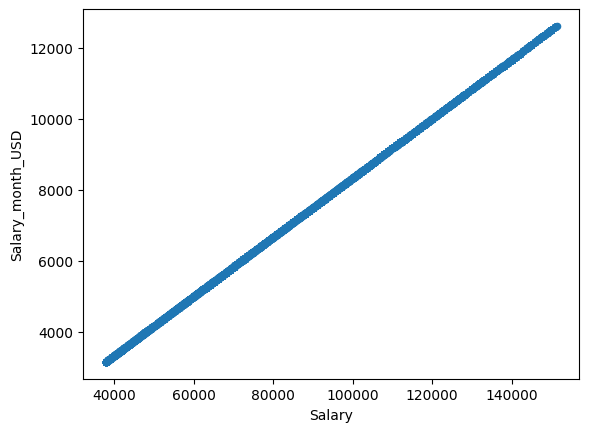

In [ ]:
df_master.plot.scatter('Salary','Salary_month_USD')

In [ ]:
df_master = df_master.drop(columns='Salary_month_USD')
df_master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13404 entries, 0 to 13403
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   USERID             13404 non-null  int64  
 1   Salary             13403 non-null  float64
 2   Compensation       13403 non-null  float64
 3   USERID             13404 non-null  int64  
 4   CGPA               13403 non-null  float64
 5   Special Bonus_GBP  13403 non-null  float64
dtypes: float64(4), int64(2)
memory usage: 628.4 KB


### **1.3 Object Identification**

In [ ]:
# Convert Special Bonus_GBP column to USD
df_master['Special Bonus_GBP'] = df_master['Special Bonus_GBP'] * 1.22 # currency rate 1GBP=1.22 USD
df_master.head()

,USERID,Salary,Compensation,USERID,CGPA,Special Bonus_GBP
0,8683,55000.0,0.0,8683,2.990627,2973.14
1,3880,62000.0,3000.0,3880,2.288131,902.80
2,8898,60000.0,7000.0,8898,3.903324,4643.32
3,4441,112000.0,10000.0,4441,2.470852,5723.02
4,7537,45000.0,0.0,7537,3.559457,5587.60


In [ ]:
df_master = df_master .rename(columns={'Special Bonus_GBP': 'Special_Bonus_USD'})
df_master.head()

,USERID,Salary,Compensation,USERID,CGPA,Special_Bonus_USD
0,8683,55000.0,0.0,8683,2.990627,2973.14
1,3880,62000.0,3000.0,3880,2.288131,902.80
2,8898,60000.0,7000.0,8898,3.903324,4643.32
3,4441,112000.0,10000.0,4441,2.470852,5723.02
4,7537,45000.0,0.0,7537,3.559457,5587.60


# **2. Data transformation - Normalization**

In [ ]:
# Min-max normalization
# Zscore/Standard normalization
# CAUTION: Normalization should only be applied after splitting the datas into training dataset and test dataset!!(Else Will affect the performance of Machine Learning)

### **2.1 Min-max normalization**

array([[<Axes: title={'center': 'USERID'}>,
        <Axes: title={'center': 'Salary'}>],
       [<Axes: title={'center': 'Compensation'}>,
        <Axes: title={'center': 'USERID'}>],
       [<Axes: title={'center': 'CGPA'}>,
        <Axes: title={'center': 'Special_Bonus_USD'}>]], dtype=object)

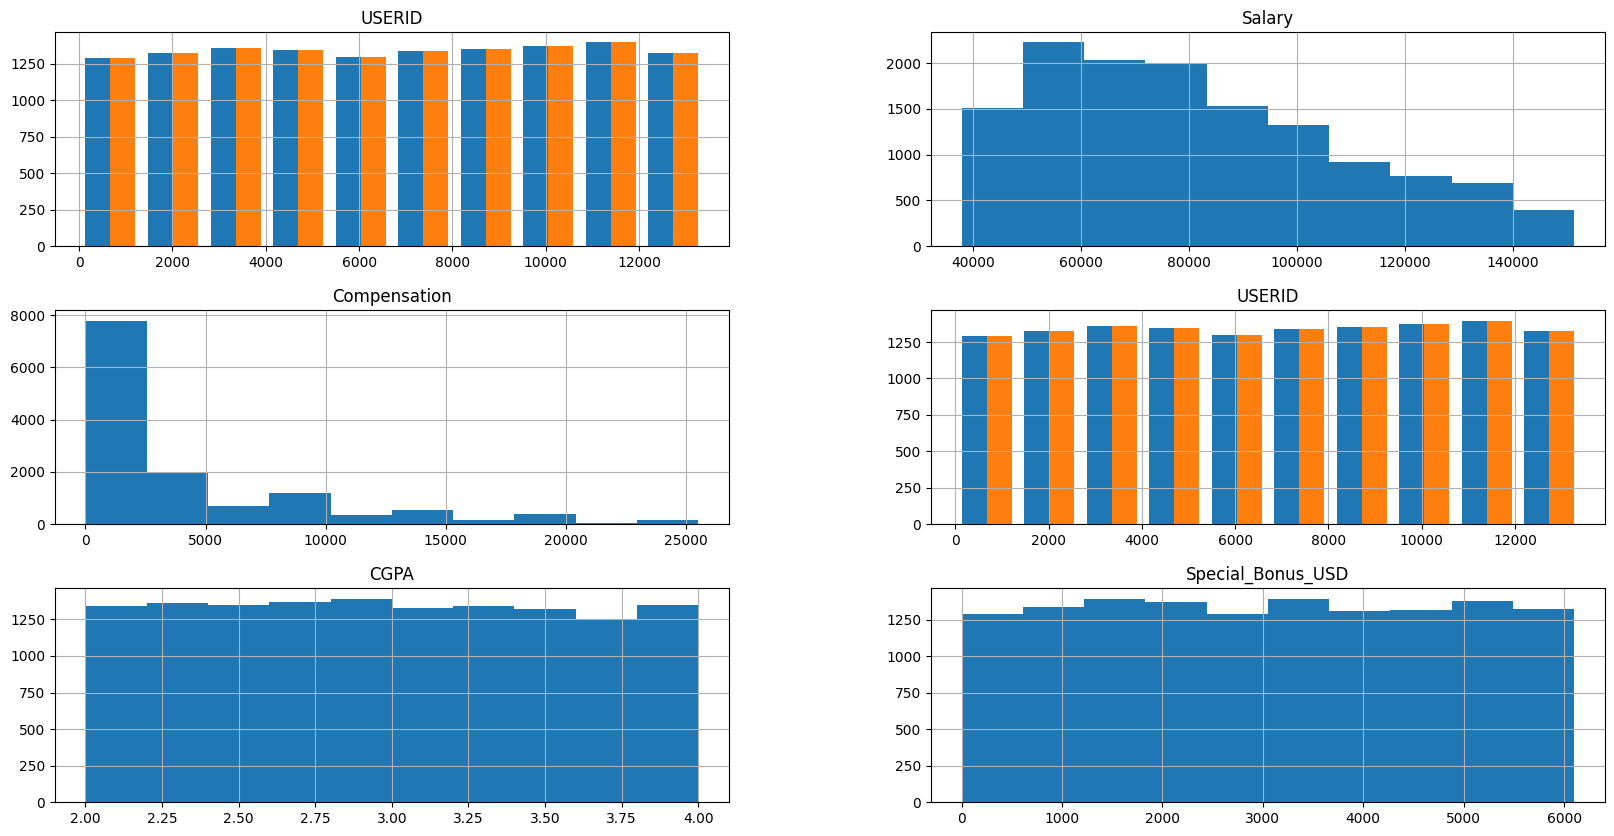

In [ ]:
#Before min-max normalization
df_master.hist(figsize=(20,10))
#df_master['Salary'].hist()
#df_master['Compensation'].hist()
#df_master['Special_Bonus_USD'].hist()

In [ ]:
from sklearn import preprocessing
m=preprocessing.MinMaxScaler(feature_range=(0, 1))
# apply normalization techniques
df_master_norm_min_max = df_master.copy()
df_master_norm_min_max[['Salary','Compensation','Special_Bonus_USD']]=m.fit_transform(df_master_norm_min_max[['Salary','Compensation','Special_Bonus_USD']])
#After min-max normalization
df_master_norm_min_max.head()

,USERID,Salary,Compensation,USERID,CGPA,Special_Bonus_USD
0,8683,0.150995,0.000000,8683,2.990627,0.4874
1,3880,0.212661,0.117647,3880,2.288131,0.1480
2,8898,0.195042,0.274510,8898,3.903324,0.7612
3,4441,0.653135,0.392157,4441,2.470852,0.9382
4,7537,0.062900,0.000000,7537,3.559457,0.9160


array([[<Axes: title={'center': 'USERID'}>,
        <Axes: title={'center': 'Salary'}>],
       [<Axes: title={'center': 'Compensation'}>,
        <Axes: title={'center': 'USERID'}>],
       [<Axes: title={'center': 'CGPA'}>,
        <Axes: title={'center': 'Special_Bonus_USD'}>]], dtype=object)

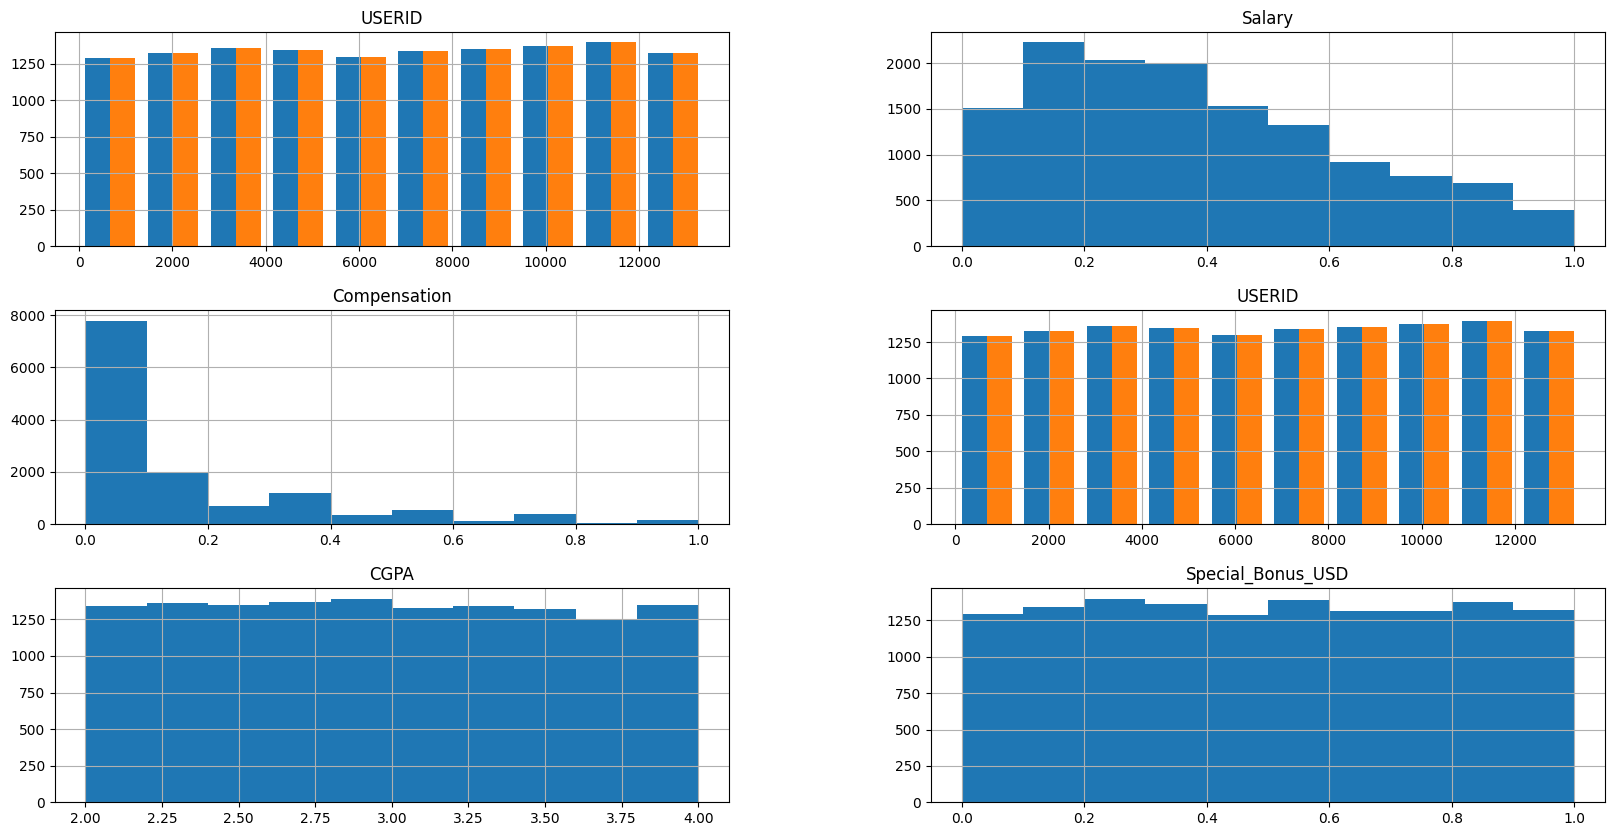

In [ ]:
df_master_norm_min_max.hist(figsize=(20,10))

### **2.2 Z-score normalization**

array([[<Axes: title={'center': 'USERID'}>,
        <Axes: title={'center': 'Salary'}>],
       [<Axes: title={'center': 'Compensation'}>,
        <Axes: title={'center': 'USERID'}>],
       [<Axes: title={'center': 'CGPA'}>,
        <Axes: title={'center': 'Special_Bonus_USD'}>]], dtype=object)

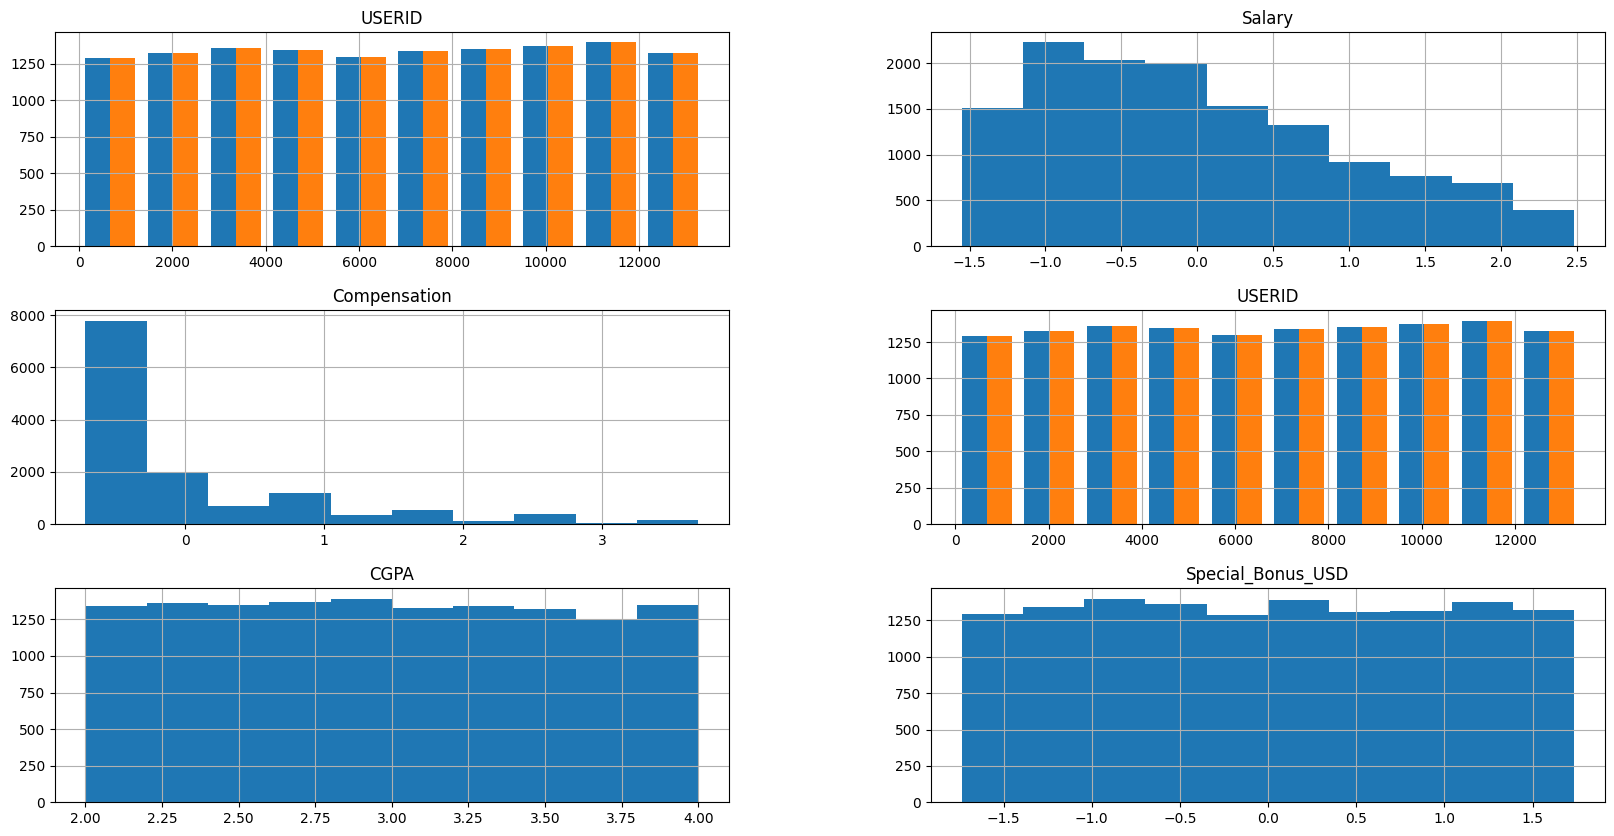

In [ ]:
m=preprocessing.StandardScaler()
# apply normalization techniques
df_master_norm_std_scaler = df_master.copy()
df_master_norm_std_scaler[['Salary','Compensation','Special_Bonus_USD']]=m.fit_transform(df_master_norm_std_scaler[['Salary','Compensation','Special_Bonus_USD']])
#After min-max normalization
df_master_norm_std_scaler.hist(figsize=(20,10))

# **3. Data Reduction**


### **3.1 Aggregation**



*   aggregate
*   groupby
*   aggregate and groupby
*   sort




In [ ]:
df_master.head()

,USERID,Salary,Compensation,USERID,CGPA,Special_Bonus_USD
0,8683,55000.0,0.0,8683,2.990627,2973.14
1,3880,62000.0,3000.0,3880,2.288131,902.80
2,8898,60000.0,7000.0,8898,3.903324,4643.32
3,4441,112000.0,10000.0,4441,2.470852,5723.02
4,7537,45000.0,0.0,7537,3.559457,5587.60


In [ ]:
df_master.agg(['min'])
#df_master['Salary'].agg(['min'])

,USERID,Salary,Compensation,USERID,CGPA,Special_Bonus_USD
min,1,37860.0,0.0,1,2.000039,0.0


In [ ]:
#df_master.info()
df_master.describe()

,USERID,Salary,Compensation,USERID,CGPA,Special_Bonus_USD
count,13404.000000,13403.000000,13403.000000,13404.000000,13403.000000,13403.000000
mean,6743.782901,81539.461315,4155.284936,6743.782901,2.992438,3051.915153
std,3862.287237,28134.315890,5778.882891,3862.287237,0.575155,1755.274933
min,1.000000,37860.000000,0.000000,1.000000,2.000039,0.000000
25%,3386.750000,59000.000000,0.000000,3386.750000,2.500295,1542.690000
50%,6787.500000,76000.000000,1500.000000,6787.500000,2.984247,3057.320000
75%,10119.000000,100000.000000,6000.000000,10119.000000,3.484162,4589.030000
max,13402.000000,151374.000000,25500.000000,13402.000000,3.999992,6100.000000


In [ ]:
print(df_master_original.columns) # To ensure there is a 'City' column

Index(['USERID', 'Timestamp', 'Age', 'Industry', 'Job title', 'Salary',
       'Compensation', 'Currency', 'Country', 'State', 'City',
       'Overall years of experience', 'Years of experience in current job',
       'Education level', 'Gender', 'USERID', 'CGPA', 'Salary_month_USD',
       'Special Bonus_GBP'],
      dtype='object')


In [ ]:
df_master['City'] = df_master_original['City']

In [ ]:
df_master = df_master.merge(
    df_master_original[['Salary', 'City']],
    on='Salary',
    how='left'
)

In [ ]:
print(df_master.columns)

Index(['USERID', 'Salary', 'Compensation', 'USERID', 'CGPA',
       'Special_Bonus_USD', 'City_x', 'City_y'],
      dtype='object')


In [ ]:
df_master = df_master.rename(columns={'City_x': 'City'})

In [ ]:
#Let's say we want to groupby city. Different cities should have different salary ranges. New York vs Wisconsin
df_master['City'].unique()
i=1
for c in df_master['City'].unique():
 print(f'{i}: {c}')
 i+=1

1: Boston
2: Milwaukee
3: Greenville
4: St. Louis
5: Palm Coast
6: Scranton
7: Detroit
8: Chicago
9: Atlanta
10: Philadelphia
11: Dayton
12: Ann Arbor
13: Silver Spring
14: Washington, DC
15: Richmond
16: Research Triangle
17: Kalamazoo
18: Manhattan
19: Sacramento
20: Arlington, VA
21: Apple Valley
22: Troy
23: Washington
24: Providence
25: District of Columbia
26: Bloomington
27: New York City
28: NYC (remotely)
29: Raleigh
30: Philadelphia (suburbs)
31: Nashville
32: Seattle
33: Indianapolis
34: Solon
35: Gainesville
36: Lafayette
37: Boulder
38: Austin
39: New York
40: Prefer not to answer
41: Kansas City
42: Dubuque
43: San Diego
44: Cambridge
45: Manassas
46: Detroit Metro area
47: Memphis
48: Dallas
49: DC
50: Denver
51: Washington DC
52: San Antonio
53: Columbus
54: Charleston
55: Madison
56: Tulsa
57: Tampa
58: Lambertville
59: Skokie
60: Alpharetta
61: Northeast Florida
62: Merced
63: Pittsburgh
64: Omaha
65: Westchester/NYC
66: San Jose
67: Grandville
68: Houston
69: Clinton

In [ ]:
# df_by_city = df_numeric.groupby('City').aggregate(['min','max','mean'])
# df_numeric.groupby('City').aggregate(['min'])
# df_master.groupby('City').aggregate(['min','max','mean'])
# df_by_city = df_numeric.groupby('City').aggregate('mean')
numeric_cols = df_master.select_dtypes(include=np.number).columns
df_by_city = df_master.groupby('City')[numeric_cols].aggregate('mean')

In [ ]:
df_by_city = df_by_city.drop(columns = ['USERID'])

In [ ]:
df_by_city.sample(5) # 5 samples of average salary by city

,Salary,Compensation,CGPA,Special_Bonus_USD
City,,,,
Montclair,74400.000000,0.000000,2.556023,821.060000
Medina,63991.176471,1014.705882,2.159851,4851.688824
"Lincoln, NE",52740.000000,0.000000,3.182838,5139.860000
Utah County,103813.953488,14219.269103,3.507320,4627.792359
Hicksville,100000.000000,3000.000000,3.381577,4797.040000


<Axes: xlabel='City'>

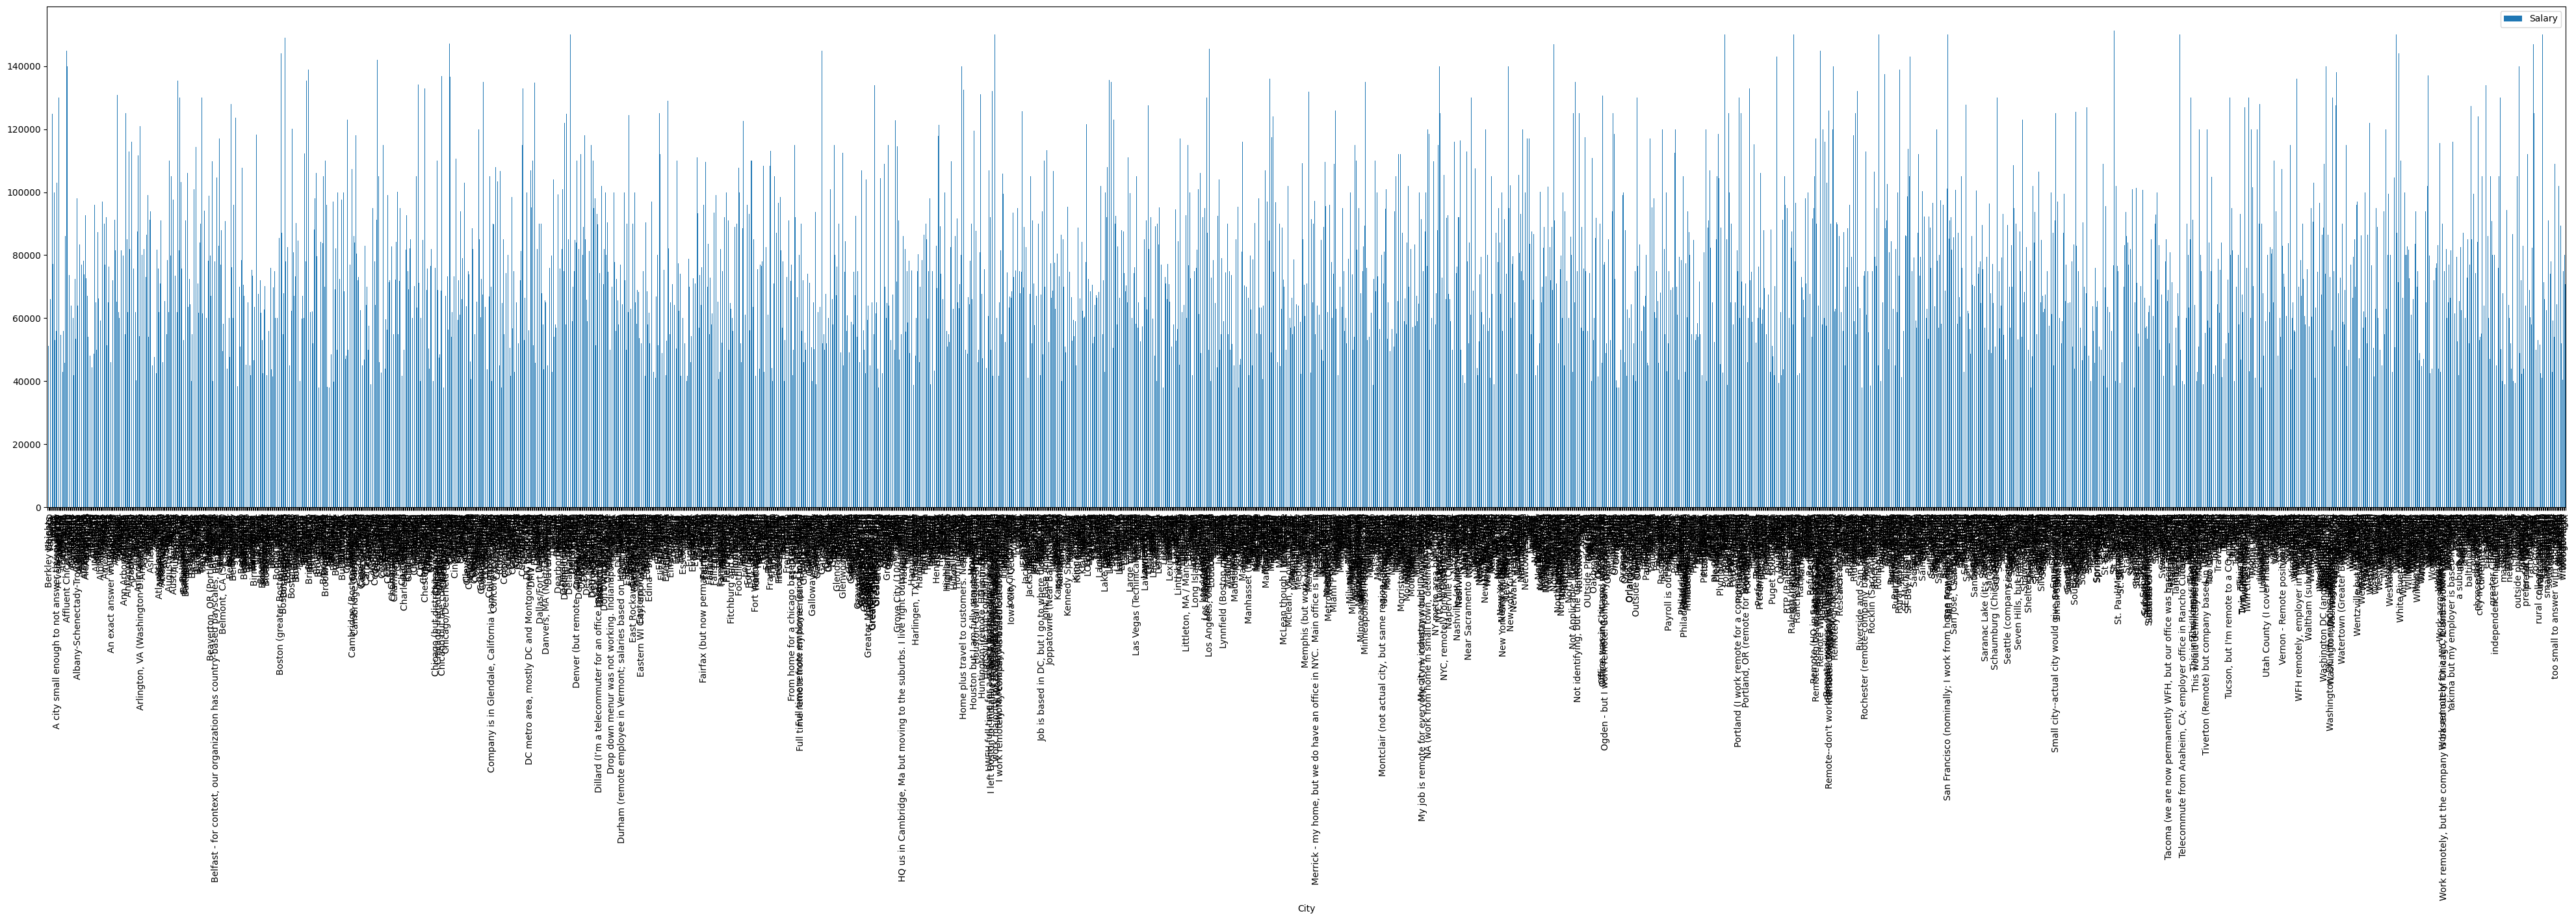

In [ ]:
df_by_city.plot.bar(y='Salary',figsize=(50,10),use_index=True,rot=90) # This bar plot doesn't show us anything

In [ ]:
df_by_city = df_by_city[df_by_city['Salary']>120000]
df_by_city.info()

<class 'pandas.core.frame.DataFrame'>
Index: 146 entries, - to san diego
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Salary             146 non-null    float64
 1   Compensation       146 non-null    float64
 2   CGPA               146 non-null    float64
 3   Special_Bonus_USD  146 non-null    float64
dtypes: float64(4)
memory usage: 5.7+ KB


<Axes: xlabel='City'>

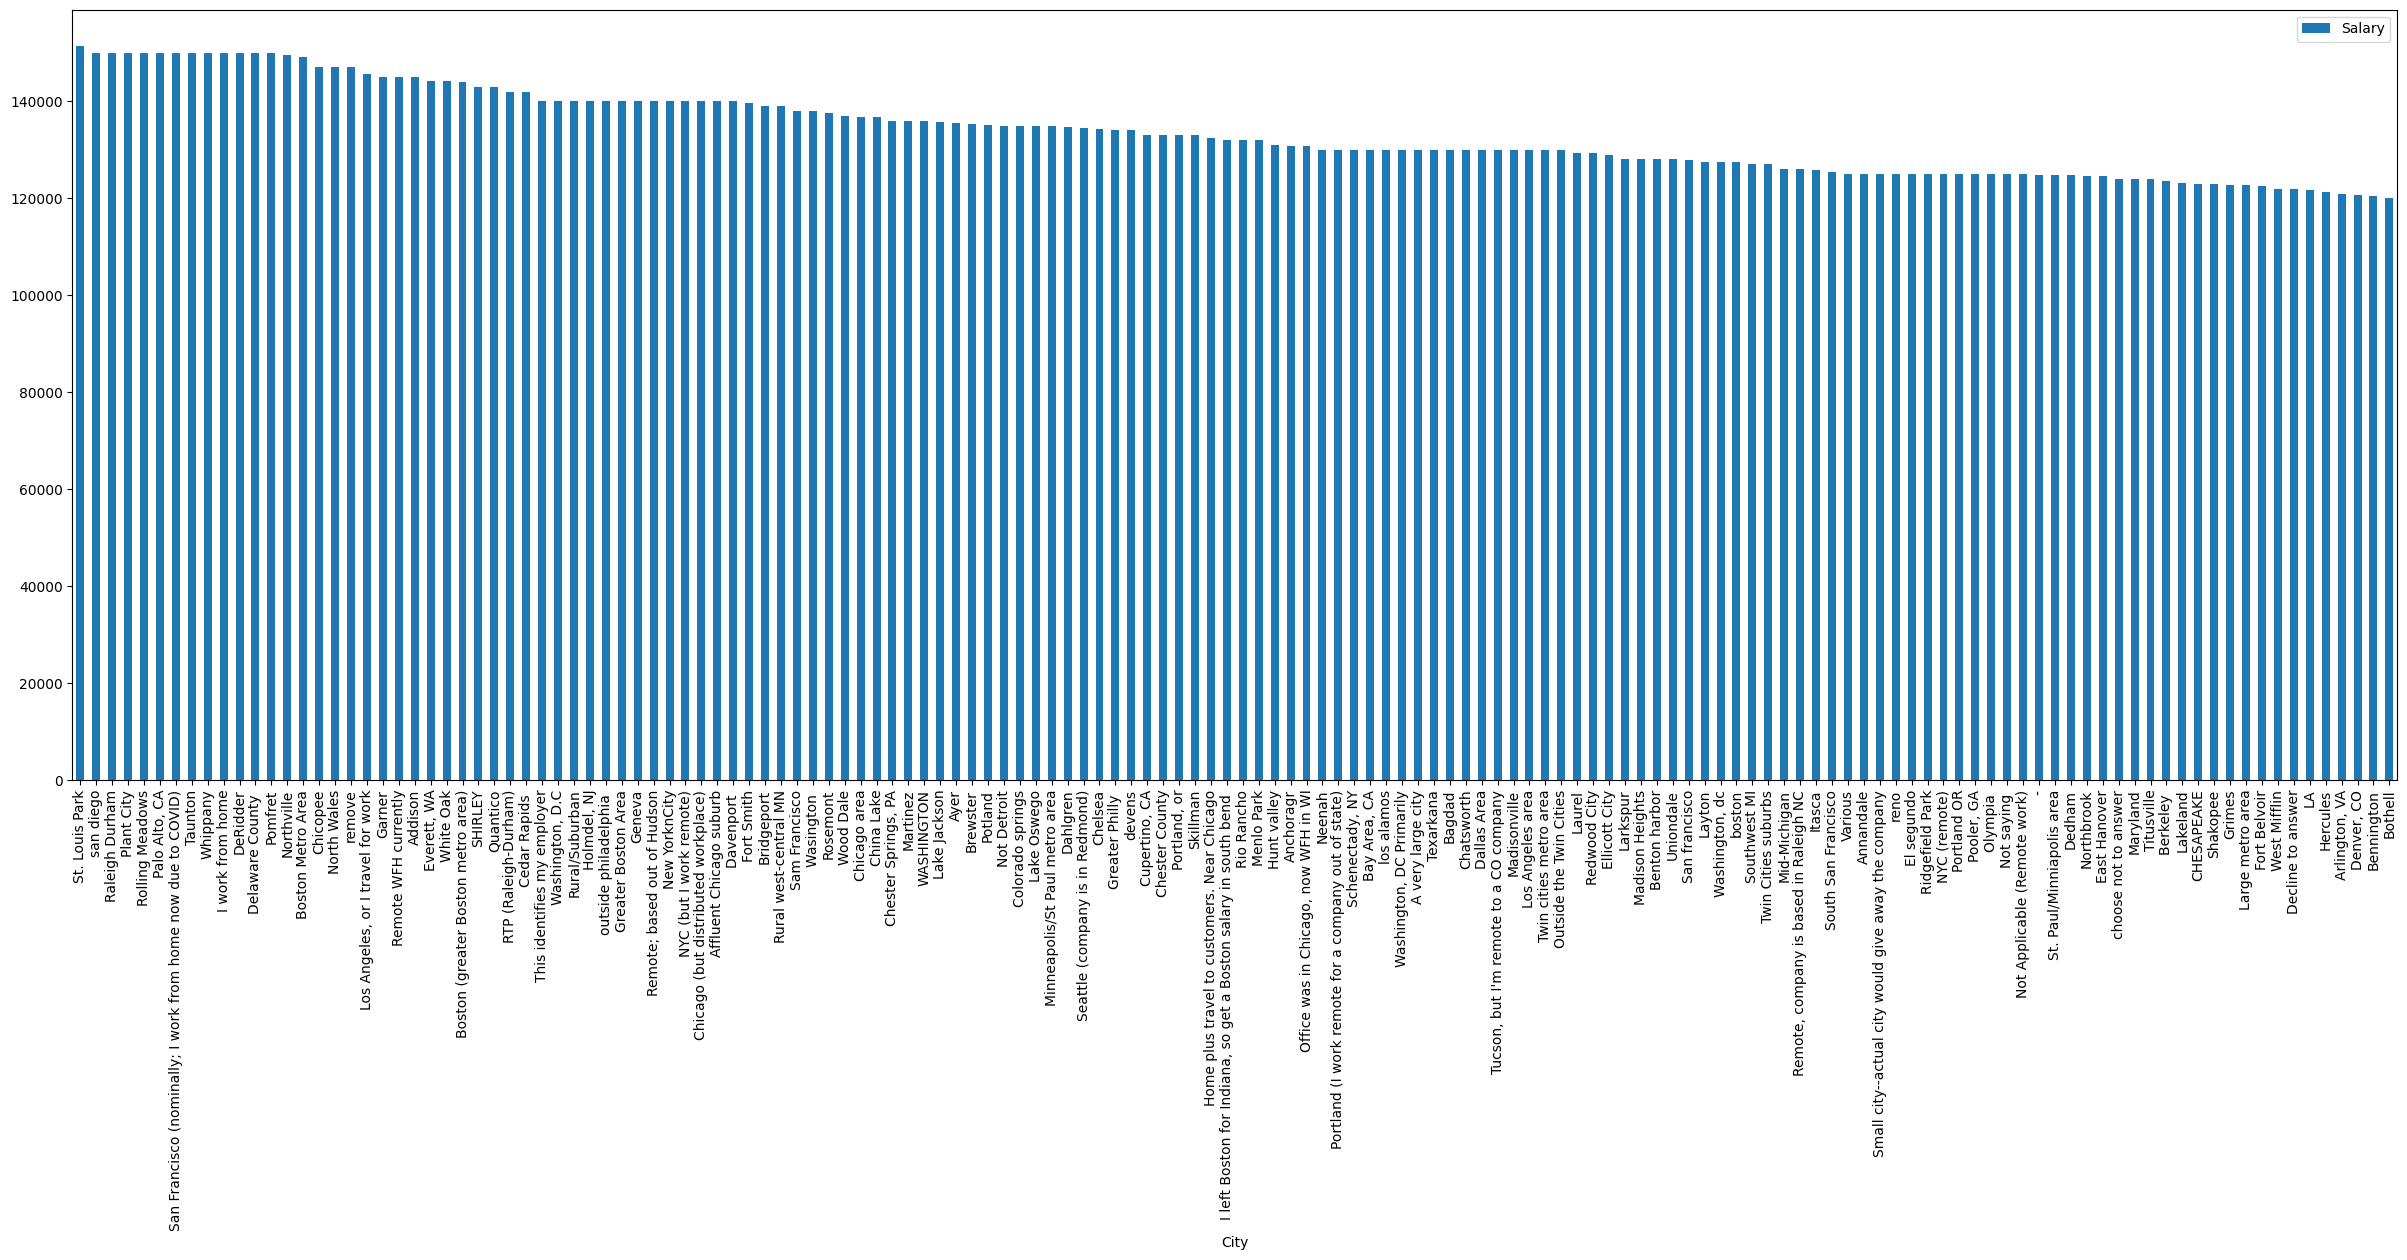

In [ ]:
df_by_city = df_by_city.sort_values(by='Salary',ascending=False)
df_by_city.plot.bar(y='Salary',figsize=(30,10),use_index=True,rot=90)
# Which city has the highest average salary, and which city has the lowest?